In [1]:
# Import the required module for this workflow.
import numpy as np
# Import the required module for this workflow.
import matplotlib.pyplot as plt
# Import a specific symbol from a module.
from pathlib import Path

# Step 0 — Inputs you assume you already have

## For each subject:

- A list of that subject’s electrode locations (3D MNI coordinates)
- One preprocessed voltage matrix: **timepoints × electrodes**

## Global:

- A pooled location list (union of all subjects’ electrode locations)
- A smoothing width value ($\lambda$), set to 20 in the paper

In this notebook version, each subject contributes one preprocessed recording, so there is no per-session split in Step 1.


In [2]:
# each subject's preprocessed file contains locs + ecog (one file per subject)
project_root = Path('/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project')
preprocessed_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')

subject_records = {}
for sub_path in sorted(preprocessed_dir.glob('*_preprocessed.npz')):
    pack = np.load(sub_path, allow_pickle=True)

    pid = str(pack['subject_id'].item())
    locs = np.asarray(pack['locs_mni_mm'], dtype=np.float32)
    ecog_shape = pack['ecog'].shape
    sample_rate_hz = int(pack['sample_rate_hz'])

    subject_records[pid] = {
        'locs': locs,
        'subject_file': sub_path,
        'sample_rate_hz': sample_rate_hz,
        'n_samples': int(ecog_shape[0]),
        'n_channels': int(ecog_shape[1]),
    }
    print(f'[{pid}] locs={locs.shape} ecog={ecog_shape} sample_rate_hz={sample_rate_hz}')

subject_ids = sorted(subject_records)
print(f'Loaded metadata for {len(subject_ids)} subjects from {preprocessed_dir}')


[aa] locs=(39, 3) ecog=(244200, 39) sample_rate_hz=1000
[ap] locs=(40, 3) ecog=(241200, 40) sample_rate_hz=1000
[ca] locs=(49, 3) ecog=(244200, 49) sample_rate_hz=1000
[de] locs=(31, 3) ecog=(244200, 31) sample_rate_hz=1000
[fp] locs=(50, 3) ecog=(244200, 50) sample_rate_hz=1000
[ha] locs=(38, 3) ecog=(242200, 38) sample_rate_hz=1000
[ja] locs=(54, 3) ecog=(244200, 54) sample_rate_hz=1000
[jt] locs=(101, 3) ecog=(244200, 101) sample_rate_hz=1000
[mv] locs=(58, 3) ecog=(244200, 58) sample_rate_hz=1000
[rn] locs=(42, 3) ecog=(244240, 42) sample_rate_hz=1000
[rr] locs=(40, 3) ecog=(162800, 40) sample_rate_hz=1000
[wc] locs=(37, 3) ecog=(244200, 37) sample_rate_hz=1000
[zt] locs=(56, 3) ecog=(244200, 56) sample_rate_hz=1000
Loaded metadata for 13 subjects from /Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed


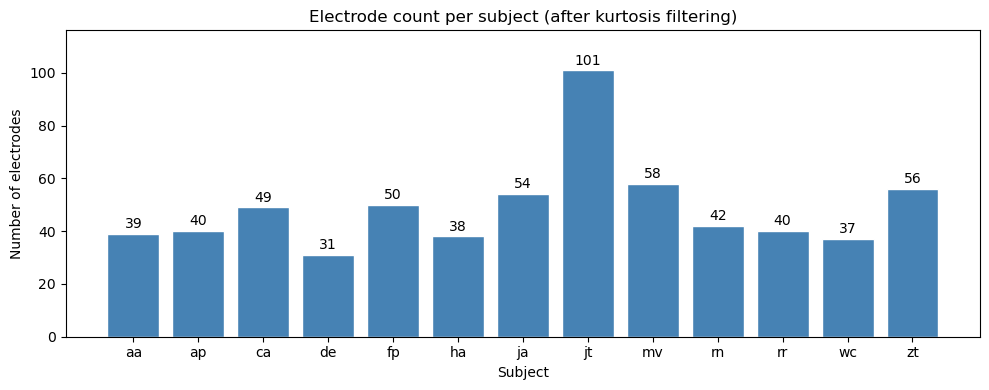

In [3]:
# Viz: electrode count per subject after kurtosis filtering
# Compute this expression and store it in `fig, ax`.
fig, ax = plt.subplots(figsize=(10, 4))
# Compute this expression and store it in `counts`.
counts = [subject_records[pid]['locs'].shape[0] for pid in subject_ids]
# Compute this expression and store it in `bars`.
bars = ax.bar(subject_ids, counts, color='steelblue', edgecolor='white')
# Compute this expression and store it in `ax.bar_label(bars, padding`.
ax.bar_label(bars, padding=2)
# Execute this line as part of the current computation step.
ax.set_xlabel('Subject')
# Execute this line as part of the current computation step.
ax.set_ylabel('Number of electrodes')
# Execute this line as part of the current computation step.
ax.set_title('Electrode count per subject (after kurtosis filtering)')
# Execute this line as part of the current computation step.
ax.set_ylim(0, max(counts) * 1.15)
# Adjust subplot spacing to reduce label overlap.
plt.tight_layout()
# Render the current figure in the notebook output.
plt.show()

In [4]:
# All subjects' electrode locations in mni
# Compute this expression and store it in `all_locs_stack`.
all_locs_stack = np.vstack([subject_records[pid]['locs'] for pid in subject_ids])
# Compute this expression and store it in `_, first_idx`.
_, first_idx = np.unique(all_locs_stack, axis=0, return_index=True)
# Compute this expression and store it in `all_electrodes`.
all_electrodes = all_locs_stack[np.sort(first_idx)].astype(np.float32)
# Compute this expression and store it in `lambda_width`.
lambda_width = 20.0

# Print a status message so you can inspect progress/output.
print(f'Pooled unique electrode locations: {all_electrodes.shape}')
# Print a status message so you can inspect progress/output.
print(f'Gaussian smoothing width (lambda): {lambda_width}')

Pooled unique electrode locations: (532, 3)
Gaussian smoothing width (lambda): 20.0


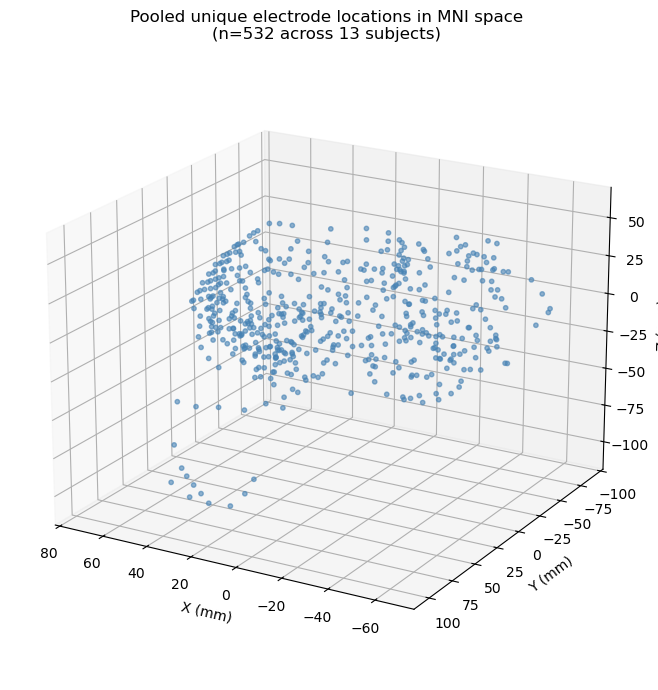

In [5]:
# Viz: 3D scatter of all pooled unique MNI electrode locations
# Compute this expression and store it in `fig`.
fig = plt.figure(figsize=(9, 7))
# Compute this expression and store it in `ax`.
ax = fig.add_subplot(111, projection='3d')
# Execute this line as part of the current computation step.
ax.scatter(all_electrodes[:, 0], all_electrodes[:, 1], all_electrodes[:, 2],
           # Compute this expression and store it in `s`.
           s=10, alpha=0.6, c='steelblue')
# Execute this line as part of the current computation step.
ax.set_xlabel('X (mm)')
# Execute this line as part of the current computation step.
ax.set_ylabel('Y (mm)')
# Execute this line as part of the current computation step.
ax.set_zlabel('Z (mm)')
# Compute this expression and store it in `ax.set_title(f'Pooled unique electrode locations in MNI space\n(n`.
ax.set_title(f'Pooled unique electrode locations in MNI space\n(n={all_electrodes.shape[0]} across {len(subject_ids)} subjects)')
# Compute this expression and store it in `ax.view_init(elev`.
ax.view_init(elev=20, azim=120)
# Adjust subplot spacing to reduce label overlap.
plt.tight_layout()
# Render the current figure in the notebook output.
plt.show()

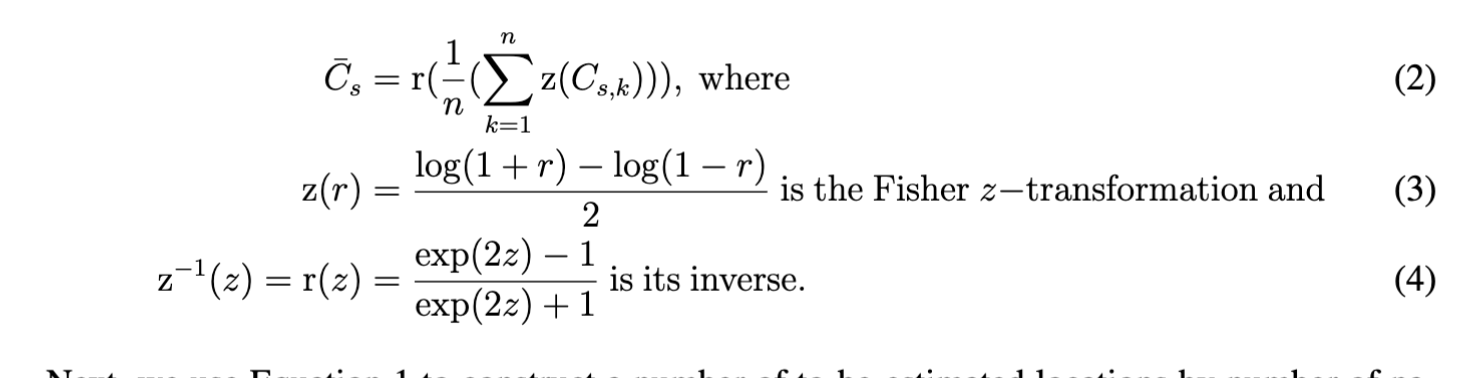

# Step 1 — Per-subject electrode–electrode correlation matrix

**Goal:** For each subject $s$, compute pairwise Pearson correlation between all of that subject’s electrodes using the full preprocessed recording.

---

For subject $s$ with voltage matrix $V^{(s)}$ of shape (timepoints × electrodes):

`compute_subject_corr(V_s) = np.corrcoef(V_s, rowvar=False)`  (Pearson correlation coefficient, electrode-by-electrode)

$$C_{s,ij} = \rho\!\left(V^{(s)}_{:,i}, V^{(s)}_{:,j}\right) \qquad \text{shape: } E_s \times E_s$$

where $E_s$ = number of electrodes for subject $s$.

Because this pipeline uses one recording per subject, this $C_s$ is the direct Step 1 output (no within-subject averaging across sessions).

**Output:** One symmetric $E_s \times E_s$ matrix $C_s$ per subject.



```
FOR each subject s:

    V^(s)    ← full preprocessed voltage matrix  (timepoints × E_s electrodes)
    C_s      ← corrcoef(V^(s), rowvar=False)     (E_s × E_s)

    # numerical cleanup
    replace NaN/inf with 0
    symmetrize C_s
    set diagonal to 1

    save C_s
```


Step 1 complete — subject-level electrode correlation matrices C_s (one session per subject):
  [aa]  samples=244200  C_s shape=(39, 39)
  [ap]  samples=241200  C_s shape=(40, 40)
  [ca]  samples=244200  C_s shape=(49, 49)
  [de]  samples=244200  C_s shape=(31, 31)
  [fp]  samples=244200  C_s shape=(50, 50)
  [ha]  samples=242200  C_s shape=(38, 38)
  [ja]  samples=244200  C_s shape=(54, 54)
  [jt]  samples=244200  C_s shape=(101, 101)
  [mv]  samples=244200  C_s shape=(58, 58)
  [rn]  samples=244240  C_s shape=(42, 42)
  [rr]  samples=162800  C_s shape=(40, 40)
  [wc]  samples=244200  C_s shape=(37, 37)
  [zt]  samples=244200  C_s shape=(56, 56)


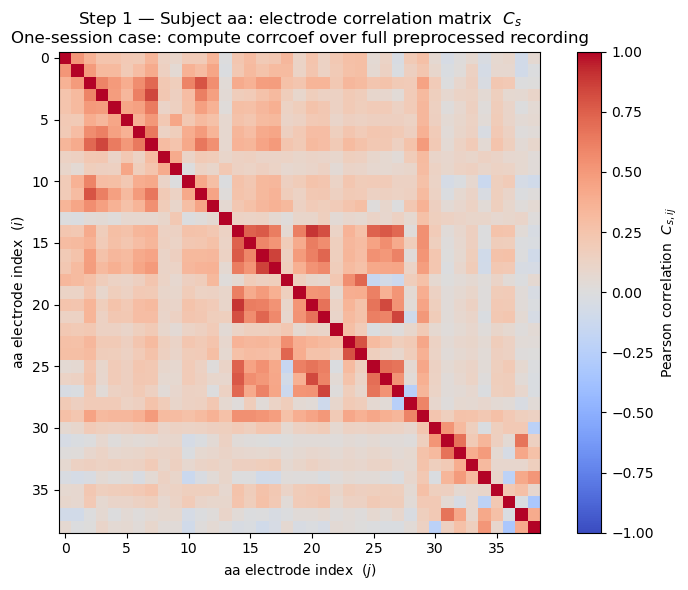

In [6]:
# Fisher-z helpers (used in later aggregation steps, e.g., Step 3A/3B; not required to form base Step 1 C_s)
#   fisher_z(r)         = arctanh(r)  — maps [-1,1] → (-∞,+∞) for linear averaging
#   inverse_fisher_z(z) = tanh(z)     — maps back
def fisher_z(corr_values):
    corr_values = np.clip(corr_values, -0.999999, 0.999999)
    return np.arctanh(corr_values)          # z = arctanh(r)

def inverse_fisher_z(z_values):
    return np.tanh(z_values)                # r = tanh(z)


# Step 1 (one-session version): one electrode-correlation matrix per subject
# No stim/session splitting is used here because each subject contributes one preprocessed recording.
C_s_matrices = {}

for pid in subject_ids:
    pack = np.load(subject_records[pid]['subject_file'], allow_pickle=True)
    ecog = np.asarray(pack['ecog'], dtype=np.float32)             # (T, E_s)

    corr_matrix = np.corrcoef(ecog, rowvar=False)                 # (E_s, E_s)
    corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, posinf=0.0, neginf=0.0)
    corr_matrix = corr_matrix.astype(np.float32, copy=False)
    corr_matrix = 0.5 * (corr_matrix + corr_matrix.T)
    np.fill_diagonal(corr_matrix, 1.0)

    C_s_matrices[pid] = corr_matrix       # C_s with one recording/session

print('Step 1 complete — subject-level electrode correlation matrices C_s (one session per subject):')
for pid in subject_ids:
    corr_shape = C_s_matrices[pid].shape
    n_samples = subject_records[pid]['n_samples']
    print(f'  [{pid}]  samples={n_samples}  C_s shape={corr_shape}')

# Visualise C_s
if 'aa' in C_s_matrices:
    aa_corr = C_s_matrices['aa']
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(aa_corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, label=r'Pearson correlation  $C_{s,ij}$')
    ax.set_title(
        r'Step 1 — Subject aa: electrode correlation matrix  $C_s$' + '\n' +
        r'One-session case: compute corrcoef over full preprocessed recording'
    )
    ax.set_xlabel(r'aa electrode index  $(j)$')
    ax.set_ylabel(r'aa electrode index  $(i)$')
    plt.tight_layout()
    plt.show()
else:
    print("Subject 'aa' not found; skipped Step 1 plot.")


# Step 2 — Gaussian distance weights &nbsp;&nbsp;*(Paper Eq. 1)*

**Goal:** For each subject $s$, build a weight matrix $\mathbf{W}^{(s)}$ that encodes how much each of their electrodes should inform each *pooled* MNI location.

---

### Eq. 1 — Gaussian kernel

$$\boxed{w_{ij} = \exp\!\left(-\frac{\|\,x_i - x_j\,\|^2}{\lambda}\right)}$$

| Symbol | Meaning |
|--------|---------|
| $x_i \in \mathbb{R}^3$ | MNI coordinate of **pooled location** $i$ (union of all subjects' electrodes) |
| $x_j \in \mathbb{R}^3$ | MNI coordinate of **subject electrode** $j$ |
| $\lambda = 20\ \text{mm}$ | Smoothing bandwidth — controls how far each electrode's influence reaches |
| $w_{ij} \to 1$ | Electrode $j$ is co-located with pooled location $i$ |
| $w_{ij} \to 0$ | Electrode $j$ is far from pooled location $i$ |

The key intuition: **an electrode only informs locations that are physically near it in the brain.** Locations with no nearby electrodes get weight ≈ 0 from this subject.

**Output:** $\mathbf{W}^{(s)}$ of shape $\underbrace{L}_{\text{pooled locs}} \times \underbrace{E_s}_{\text{subject electrodes}}$ — one matrix per subject.

```
FOR each subject s:

    W^(s) ← zeros(L, E_s)          # L pooled locs, E_s subject electrodes

    FOR each pooled location i  (coordinate x_i):
        FOR each subject electrode j  (coordinate x_j):

            # squared Euclidean distance in MNI space
            d²_ij  = ||x_i − x_j||²

            # Eq. 1: Gaussian falloff
            W^(s)[i, j] = exp( −d²_ij / λ )    # λ = 20 mm

    # W^(s) shape: (L × E_s)
    # Each row  i : how much every electrode informs pooled location i
    # Each col  j : how much electrode j informs every pooled location
    #              → a Gaussian "blob" centred on electrode j's MNI position
```

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Paper Eq. 1 — Gaussian distance kernel:
#
#   w_ij = exp( −||x_i − x_j||² / λ )
#
#   i  → index over pooled MNI locations    (L = 532 rows)
#   j  → index over subject electrodes      (E_s columns)
#   λ  → smoothing bandwidth = 20 mm        (lambda_width)
#
#   W^(s) shape: (L × E_s)
#     W[i, j] → 1  when pooled location i ≈ electrode j
#     W[i, j] → 0  as Euclidean distance between them grows
# ─────────────────────────────────────────────────────────────────────────────
# Compute this expression and store it in `subject_weights`.
subject_weights = {}

# Start a loop over the specified collection.
for pid in subject_ids:
    # Compute this expression and store it in `subject_locs`.
    subject_locs = subject_records[pid]['locs']              # x_j : (E_s, 3)

    # broadcast subtract: (L,1,3) − (1,E_s,3)  →  (L, E_s, 3)
    # Compute this expression and store it in `diffs`.
    diffs = all_electrodes[:, None, :] - subject_locs[None, :, :]

    # ||x_i − x_j||²  element-wise  →  (L, E_s)
    # Compute this expression and store it in `distance_squared`.
    distance_squared = np.sum(diffs * diffs, axis=2)

    # Eq. 1:  w_ij = exp( −||x_i − x_j||² / λ )
    # Compute this expression and store it in `weights`.
    weights = np.exp(-distance_squared / lambda_width).astype(np.float32, copy=False)

    # Compute this expression and store it in `subject_weights[pid]`.
    subject_weights[pid] = weights                           # W^(s) : (L, E_s)

# Print a status message so you can inspect progress/output.
print('Step 2 complete — Gaussian weight matrices W^(s)  (Eq. 1):')
# Start a loop over the specified collection.
for pid in subject_ids:
    # Print a status message so you can inspect progress/output.
    print(f'  [{pid}]  W^(s) shape={subject_weights[pid].shape}')

Step 2 complete — Gaussian weight matrices W^(s)  (Eq. 1):
  [aa]  W^(s) shape=(532, 39)
  [ap]  W^(s) shape=(532, 40)
  [ca]  W^(s) shape=(532, 49)
  [de]  W^(s) shape=(532, 31)
  [fp]  W^(s) shape=(532, 50)
  [ha]  W^(s) shape=(532, 38)
  [ja]  W^(s) shape=(532, 54)
  [jt]  W^(s) shape=(532, 101)
  [mv]  W^(s) shape=(532, 58)
  [rn]  W^(s) shape=(532, 42)
  [rr]  W^(s) shape=(532, 40)
  [wc]  W^(s) shape=(532, 37)
  [zt]  W^(s) shape=(532, 56)


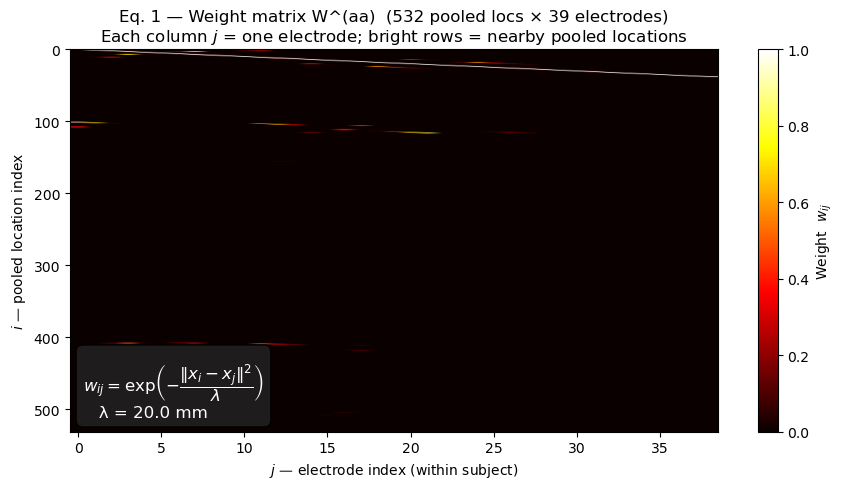

(532, 39)

In [8]:
# Viz: Step 2 — one subject weight matrix W^(s)
# Step 3 uses W^(s) with shape (L, E_s), so show a single subject here.
# Compute this expression and store it in `pid_ex`.
pid_ex = 'aa'
# Compute this expression and store it in `W`.
W = subject_weights[pid_ex]   # (532, E_s)

# Compute this expression and store it in `fig, ax`.
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

# Compute this expression and store it in `im`.
im = ax.imshow(W, aspect='auto', cmap='hot', vmin=0, vmax=1)
# Compute this expression and store it in `plt.colorbar(im, ax`.
plt.colorbar(im, ax=ax, label=r'Weight  $w_{ij}$')
# Execute this line as part of the current computation step.
ax.set_xlabel(r'$j$ — electrode index (within subject)')
# Execute this line as part of the current computation step.
ax.set_ylabel(r'$i$ — pooled location index')
# Execute this line as part of the current computation step.
ax.set_title(
    # Execute this line as part of the current computation step.
    f"Eq. 1 — Weight matrix W^({pid_ex})  (532 pooled locs × {W.shape[1]} electrodes)" + '\n'
    # Compute this expression and store it in `r'Each column $j$`.
    r'Each column $j$ = one electrode; bright rows = nearby pooled locations'
# Close the current argument list or container literal.
)
# Formula box on the plot
# Execute this line as part of the current computation step.
ax.text(
    # Execute this line as part of the current computation step.
    0.02, 0.03,
    # Compute this expression and store it in `r'$w_{ij}`.
    r'$w_{ij} = \exp\!\left(-\dfrac{\|x_i - x_j\|^2}{\lambda}\right)$'
    # Compute this expression and store it in `+ f'\n   λ`.
    + f'\n   λ = {lambda_width} mm',
    # Compute this expression and store it in `transform`.
    transform=ax.transAxes, fontsize=12, va='bottom', color='white',
    # Compute this expression and store it in `bbox`.
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#222222', alpha=0.85)
# Close the current argument list or container literal.
)

# Adjust subplot spacing to reduce label overlap.
plt.tight_layout()
# Render the current figure in the notebook output.
plt.show()

W.shape

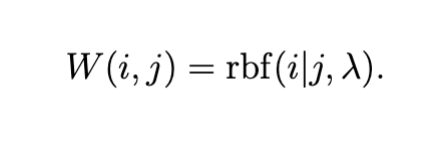

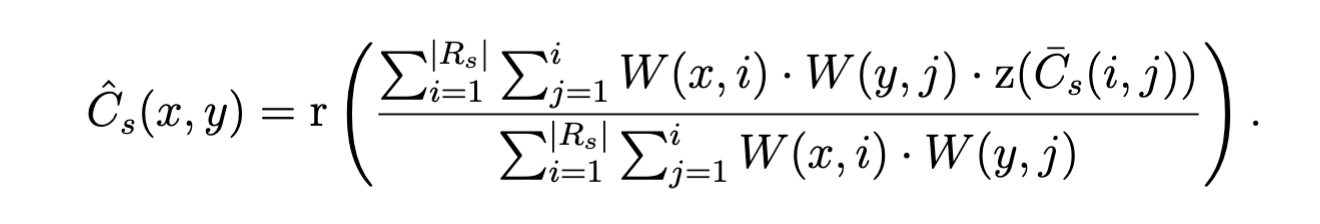

# Step 3A — Subject-specific full-brain correlation matrix &nbsp;&nbsp;*(Paper Eq. 6)*

**Goal:** Use subject $s$'s electrode correlations $C_s$ (Step 1) and Gaussian weights $\mathbf{W}^{(s)}$ (Step 2) to estimate the correlation between **any two pooled MNI locations** — including locations where subject $s$ has no electrode.

---

### Eq. 6 — Gaussian-weighted interpolation

**Scalar form** (element $\hat{C}_s(x,y)$ = estimated correlation between pooled locations $x$ and $y$):

$$\hat{C}_s(x,y) = \tanh\!\left(\frac{\displaystyle\sum_{i,j}\, w_{xi}\, w_{yj}\; \text{arctanh}\!\left(C_{s,ij}\right)}{\displaystyle\sum_{i,j}\, w_{xi}\, w_{yj}}\right)$$

**Matrix form** (equivalent — and what the code actually computes):

$$\boxed{\hat{\mathbf{C}}_s = \tanh\!\left(\frac{\mathbf{W}^{(s)}\;\text{arctanh}\!\left(\mathbf{C}_s\right)\;{\mathbf{W}^{(s)}}^\top}{\mathbf{W}^{(s)}\;\mathbf{1}\;{\mathbf{W}^{(s)}}^\top}\right)}$$

| Term | Shape | Role |
|------|-------|------|
| $\mathbf{W}^{(s)}$ | $L \times E_s$ | Gaussian weights (Step 2 / Eq. 1) |
| $\mathbf{C}_s$ | $E_s \times E_s$ | Subject electrode correlations (Step 1) |
| $\mathbf{1}$ | $E_s \times E_s$ | All-ones matrix — normalises by total weight |
| $\hat{\mathbf{C}}_s$ | $L \times L$ | Estimated full-brain correlation matrix |

---

### What “Gaussian smoothing” means here (plain language)

1. Each pooled location gets a **weight to every electrode** from subject $s$.
2. Nearby electrodes get high weights; far electrodes get low weights.
3. So each pooled location is represented as a **weighted blend** of that subject's electrodes.
4. Correlation between two pooled locations is computed from how their two blends overlap through $C_s$.
5. **Larger $\lambda$** spreads influence farther (broader smoothing). **Smaller $\lambda$** keeps influence local.

So smoothing is not averaging neighboring matrix pixels; it is spatially spreading electrode influence across nearby pooled coordinates before correlations are estimated.

The division is **element-wise**. Where a subject has no electrodes near a pooled location, the denominator ≈ 0 and that entry is zeroed out (eps guard in code).

**Output:** One $(L \times L)$ matrix $\hat{\mathbf{C}}_s$ per subject. With $L = 532$, this is a $532 \times 532$ estimated full-brain correlation structure derived from that subject's sparse electrode coverage.


```
FOR each subject s:

    C_s     ← C_s_matrices[s]   # (E_s × E_s)  from Step 1
    W^(s)   ← subject_weights[s]                         # (L × E_s)  from Step 2

    # --- Matrix form of Eq. 6 ---

    # Fisher-z the electrode correlations first
    Z^(s)        = arctanh( C_s )                        # (E_s × E_s)

    # Numerator:   W @ arctanh(C) @ Wᵀ
    numerator    = W^(s)  @  Z^(s)  @  W^(s)ᵀ           # (L × L)
    #   Each entry (x,y): Σ_{i,j} w_xi · arctanh(C_ij) · w_yj

    # Denominator: W @ ones @ Wᵀ   (= sum of all pairwise weights)
    denominator  = W^(s)  @  ones(E_s,E_s)  @  W^(s)ᵀ   # (L × L)
    #   Each entry (x,y): Σ_{i,j} w_xi · w_yj

    # Eq. 6 complete:
    C_hat_s = tanh( numerator / denominator )             # (L × L)  ← OUTPUT
    #   = tanh( Σ w_xi·w_yj·arctanh(C_ij) / Σ w_xi·w_yj )
```


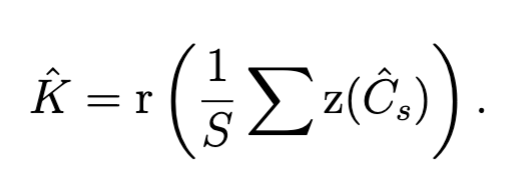

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Paper Eq. 6 — Gaussian-weighted interpolation (matrix form):
#
#   Scalar:  C_hat_s(x,y) = tanh( Σ_{i,j} w_xi·w_yj·arctanh(C_ij)
#                             / Σ_{i,j} w_xi·w_yj )
#
#   Matrix:  C_hat_s = tanh( numerator / denominator )   [element-wise /]
#     where
#       numerator   = W^(s)  @  arctanh(C_s)      @  W^(s)ᵀ   (L × L)
#       denominator = W^(s)  @  ones(E_s,E_s)    @  W^(s)ᵀ   (L × L)
#
#   W^(s)  : (L × E_s)  Gaussian weights          [Step 2 / Eq. 1]
#   C_s      : (E_s × E_s) electrode correlations   [Step 1]
#   C_hat_s  : (L × L)    estimated full-brain correlation
#
#   Denominator ≈ 0 where a subject has no nearby electrodes → zeroed out.
# ─────────────────────────────────────────────────────────────────────────────
# Compute this expression and store it in `C_hat_s_matrices`.
C_hat_s_matrices = {}
# Compute this expression and store it in `eps`.
eps = 1e-12

# Start a loop over the specified collection.
for pid in subject_ids:
    # Compute this expression and store it in `electrode_corr`.
    electrode_corr = C_s_matrices[pid]   # C_s : (E_s, E_s)
    # Compute this expression and store it in `weights`.
    weights        = subject_weights[pid]                         # W^(s)  : (L,   E_s)

    # Fisher-z the electrode correlations: arctanh( C_s )
    # Compute this expression and store it in `corr_z`.
    corr_z      = fisher_z(electrode_corr).astype(np.float32, copy=False)  # (E_s, E_s)

    # numerator:   W^(s) @ arctanh(C_s) @ W^(s)ᵀ
    # Compute this expression and store it in `numerator`.
    numerator   = weights @ corr_z @ weights.T                   # (L, L)

    # denominator: W^(s) @ ones @ W^(s)ᵀ   (sum of all pairwise weights)
    # Compute this expression and store it in `denominator`.
    denominator = weights @ np.ones_like(corr_z, dtype=np.float32) @ weights.T  # (L, L)

    # element-wise division (eps guard where denominator ≈ 0)
    # Compute this expression and store it in `mean_z`.
    mean_z = np.divide(
        # Execute this line as part of the current computation step.
        numerator,
        # Execute this line as part of the current computation step.
        denominator,
        # Compute this expression and store it in `out`.
        out=np.zeros_like(numerator, dtype=np.float32),
        # Compute this expression and store it in `where`.
        where=denominator > eps,
    # Close the current argument list or container literal.
    )

    # Eq. 6 complete: C_hat_s = tanh( numerator / denominator )
    # Compute this expression and store it in `subject_full_matrix`.
    subject_full_matrix = inverse_fisher_z(mean_z).astype(np.float32, copy=False)
    # Compute this expression and store it in `subject_full_matrix`.
    subject_full_matrix = 0.5 * (subject_full_matrix + subject_full_matrix.T)  # symmetry
    # Set the matrix diagonal entries to the requested value.
    np.fill_diagonal(subject_full_matrix, 1.0)

    # Compute this expression and store it in `C_hat_s_matrices[pid]`.
    C_hat_s_matrices[pid] = subject_full_matrix             # C_hat_s : (L, L)

# Print a status message so you can inspect progress/output.
print('Step 3A complete — subject-specific full-brain matrices C_hat_s  (Eq. 6):')
# Start a loop over the specified collection.
for pid in subject_ids:
    # Print a status message so you can inspect progress/output.
    print(f'  [{pid}]  C_hat_s shape={C_hat_s_matrices[pid].shape}')

Step 3A complete — subject-specific full-brain matrices C_hat_s  (Eq. 6):
  [aa]  C_hat_s shape=(532, 532)
  [ap]  C_hat_s shape=(532, 532)
  [ca]  C_hat_s shape=(532, 532)
  [de]  C_hat_s shape=(532, 532)
  [fp]  C_hat_s shape=(532, 532)
  [ha]  C_hat_s shape=(532, 532)
  [ja]  C_hat_s shape=(532, 532)
  [jt]  C_hat_s shape=(532, 532)
  [mv]  C_hat_s shape=(532, 532)
  [rn]  C_hat_s shape=(532, 532)
  [rr]  C_hat_s shape=(532, 532)
  [wc]  C_hat_s shape=(532, 532)
  [zt]  C_hat_s shape=(532, 532)


In [10]:
subject_full_matrix.shape

(532, 532)

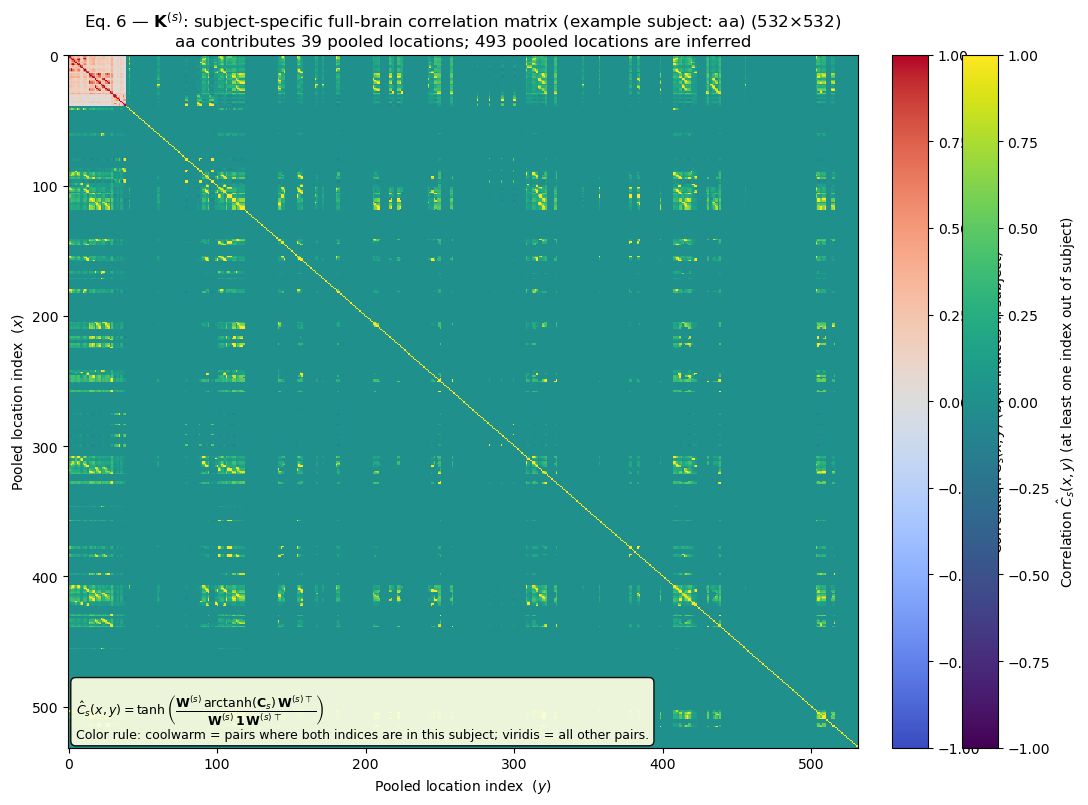

In [11]:
# Viz: Step 3A — example subject full-brain matrix C_hat_s

pid_ex = 'aa'
M = C_hat_s_matrices[pid_ex]       # C_hat_s for this subject : (L, L)
subject_locs = subject_records[pid_ex]['locs']

# Mark which pooled locations are directly in the example subject.
pooled_round = np.round(all_electrodes, 3)
subject_round = np.round(subject_locs, 3)
subject_set = {tuple(row) for row in subject_round.tolist()}
in_subject = np.array([tuple(row) in subject_set for row in pooled_round.tolist()], dtype=bool)

# Pair-level masks:
# in-subject pair     = both pooled indices are in this subject
# out-of-subject pair = at least one pooled index is not in this subject
in_pair_mask = np.outer(in_subject, in_subject)
not_in_pair_mask = ~in_pair_mask

n_total = M.shape[0]
n_in_subject = int(in_subject.sum())
n_not_in_subject = int((~in_subject).sum())

# Build masked matrices so each pair group can use its own continuous colormap.
M_in = np.ma.masked_where(~in_pair_mask, M)
M_not = np.ma.masked_where(~not_in_pair_mask, M)

# Use two different continuous color scales for correlation values.
cmap_in = plt.colormaps['coolwarm'].copy()   # in-subject pairs
cmap_not = plt.colormaps['viridis'].copy()   # out-of-subject pairs
cmap_in.set_bad((0, 0, 0, 0))
cmap_not.set_bad((0, 0, 0, 0))

# Figure layout: large heatmap + two correlation colorbars.
fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[1.0, 0.045, 0.045],
    wspace=0.12,
)

ax = fig.add_subplot(gs[0, 0])
cax_in = fig.add_subplot(gs[0, 1])
cax_not = fig.add_subplot(gs[0, 2])

# Draw out-of-subject pairs first, then in-subject pairs on top.
im_not = ax.imshow(M_not, aspect='auto', cmap=cmap_not, vmin=-1, vmax=1, interpolation='nearest')
im_in = ax.imshow(M_in, aspect='auto', cmap=cmap_in, vmin=-1, vmax=1, interpolation='nearest')

cb_in = fig.colorbar(im_in, cax=cax_in)
cb_in.set_label(r'Correlation $\hat{C}_s(x,y)$ (both indices in subject)')

cb_not = fig.colorbar(im_not, cax=cax_not)
cb_not.set_label(r'Correlation $\hat{C}_s(x,y)$ (at least one index out of subject)')

ax.set_xlabel(r'Pooled location index  $(y)$')
ax.set_ylabel(r'Pooled location index  $(x)$')
ax.set_title(
    fr'Eq. 6 — $\mathbf{{K}}^{{(s)}}$: subject-specific full-brain correlation matrix (example subject: {pid_ex}) ({n_total}×{n_total})' + '\n' +
    fr'{pid_ex} contributes {n_in_subject} pooled locations; {n_not_in_subject} pooled locations are inferred'
)

# Formula + short intuition.
ax.text(
    0.01,
    0.01,
    r'$\hat{C}_s(x,y)=\tanh\left(\dfrac{\mathbf{W}^{(s)}\,\mathrm{arctanh}(\mathbf{C}_s)\,{\mathbf{W}^{(s)}}^\top}{\mathbf{W}^{(s)}\,\mathbf{1}\,{\mathbf{W}^{(s)}}^\top}\right)$' + '\n' +
    r'Color rule: coolwarm = pairs where both indices are in this subject; viridis = all other pairs.',
    transform=ax.transAxes,
    fontsize=9,
    va='bottom',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.92),
)

plt.show()


# Step 3B — Across-subject average correlation matrix &nbsp;&nbsp;*(Paper Eq. 7)*

**Goal:** Collapse the $S$ subject-specific matrices $\hat{\mathbf{C}}_s$ into a single group-level full-brain correlation matrix using Fisher-z averaging **across subjects**:

$$\boxed{\hat{\mathbf{K}} = \tanh\!\left(\frac{1}{S} \sum_{s=1}^{S} \text{arctanh}\!\left(\hat{\mathbf{C}}_s\right)\right)}$$

This is **Eq. 7** from the paper. Each subject contributes equally; Fisher-z keeps averaging well-behaved for correlation values.

**Output:** One symmetric $(L \times L)$ matrix $\hat{\mathbf{K}}$ — the group-level estimated pairwise correlation structure across all pooled brain locations.



```
# Eq. 7 — Fisher-z average of subject-specific C_hat_s matrices

all_C_hat_s  ← stack( C_hat_s for all subjects s )    # (S, L, L)

mean_z ← mean_s( arctanh( all_C_hat_s ) )           # (L, L)
K_hat  ← tanh( mean_z )                        # (L, L)  ← OUTPUT  (group-level)
```


Step 3B complete — across-subject matrix K_hat (paper: \hat{K}) (Eq. 7):
  shape = (532, 532)
  min=-0.0530  max=1.0000
  max symmetry error = 0.00e+00


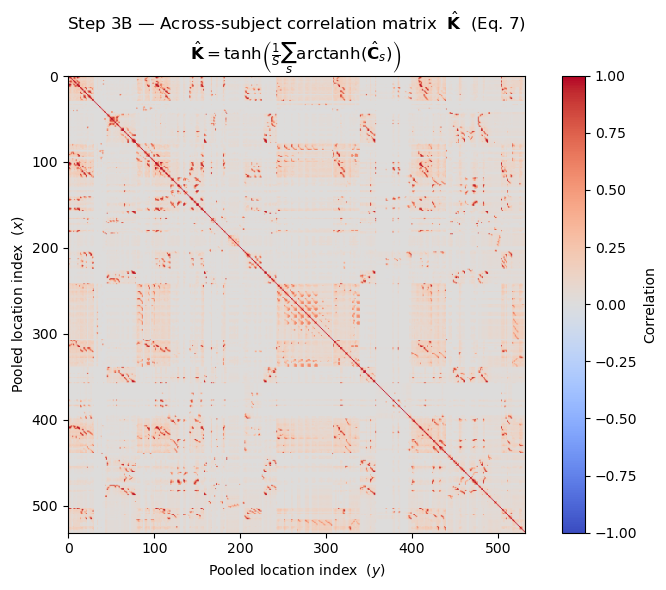

Saved to /Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/electrode_correlation_outputs.npz


In [ ]:
# Eq. 7 — Fisher-z average across subjects:
#   K_hat = tanh( (1/S) · Σ_s arctanh( C_hat_s ) )
# Compute this expression and store it in `all_C_hat_s`.
all_C_hat_s = np.stack(
    # Compute this expression and store it in `[C_hat_s_matrices[pid] for pid in subject_ids], axis`.
    [C_hat_s_matrices[pid] for pid in subject_ids], axis=0
# Execute this line as part of the current computation step.
)  # (S, L, L)

# (1/S) Σ_s arctanh(C_hat_s)  — average in Fisher-z space
# Compute this expression and store it in `mean_z`.
mean_z = fisher_z(all_C_hat_s).mean(axis=0)       # (L, L)

# tanh(·)  — inverse Fisher-z back to correlation scale
# Compute this expression and store it in `K_hat`.
K_hat = inverse_fisher_z(mean_z).astype(np.float32, copy=False)
# Compute this expression and store it in `K_hat`.
K_hat = 0.5 * (
    # Execute this line as part of the current computation step.
    K_hat + K_hat.T
# Close the current argument list or container literal.
)
# Set the matrix diagonal entries to the requested value.
np.fill_diagonal(K_hat, 1.0)

# Print a status message so you can inspect progress/output.
print('Step 3B complete — across-subject matrix K_hat (paper: \hat{K}) (Eq. 7):')
# Print a status message so you can inspect progress/output.
print(f'  shape = {K_hat.shape}')
# Print a status message so you can inspect progress/output.
print(f'  min={K_hat.min():.4f}  max={K_hat.max():.4f}')
# Print a status message so you can inspect progress/output.
print(f'  max symmetry error = {np.abs(K_hat - K_hat.T).max():.2e}')

# Compute this expression and store it in `fig, ax`.
fig, ax = plt.subplots(figsize=(8, 6))
# Compute this expression and store it in `im`.
im = ax.imshow(K_hat, cmap='coolwarm', vmin=-1, vmax=0)
# Compute this expression and store it in `plt.colorbar(im, ax`.
plt.colorbar(im, ax=ax, label='Correlation')
# Execute this line as part of the current computation step.
ax.set_title(
    # Execute this line as part of the current computation step.
    r'Step 3B — Across-subject correlation matrix  $\hat{\mathbf{K}}$  (Eq. 7)' + '\n' +
    # Compute this expression and store it in `r'$\mathbf{K}`.
    r'$\hat{\mathbf{K}} = \tanh\!\left(\frac{1}{S}\sum_s \mathrm{arctanh}(\hat{\mathbf{C}}_s)\right)$'
# Close the current argument list or container literal.
)
# Execute this line as part of the current computation step.
ax.set_xlabel('Pooled location index  $(y)$')
# Execute this line as part of the current computation step.
ax.set_ylabel('Pooled location index  $(x)$')
# Adjust subplot spacing to reduce label overlap.
plt.tight_layout()
# Render the current figure in the notebook output.
plt.show()

# Compute this expression and store it in `output_path`.
output_path = project_root / 'electrode_correlation_outputs.npz'
# Save the computed outputs to a compressed NPZ file.
np.savez_compressed(
    # Execute this line as part of the current computation step.
    output_path,
    # Compute this expression and store it in `pooled_locations_mni_mm`.
    pooled_locations_mni_mm=all_electrodes,
    # Compute this expression and store it in `subject_ids`.
    subject_ids=np.array(subject_ids, dtype=object),
    # Compute this expression and store it in `C_hat_s_matrices`.
    C_hat_s_matrices=all_C_hat_s,
    # Compute this expression and store it in `K_hat`.
    K_hat=K_hat,
# Close the current argument list or container literal.
)
# Print a status message so you can inspect progress/output.
print(f'Saved to {output_path}')

In [25]:
K_hat.shape

(532, 532)

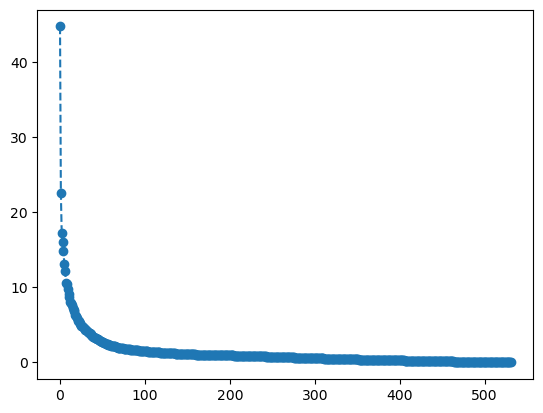

In [24]:
U,S,V = np.linalg.svd(K_hat)
plt.plot(S,'o--')

# ----- SINGLE ELECTRODE PREDICTION --------

# Step 3C — Build **leakage-free** K for a held-out subject

To avoid leakage, when reconstructing subject `s`, build `K` using **all other subjects only** (exclude `s`).

- `K_hat_no_leak[held_out_pid]` = average of subject full matrices from `subject_ids \ {held_out_pid}`
- Averaging uses Fisher-z, then inverse Fisher-z (same as Step 3B)


Held-out subject: aa
Training subjects used to build K_hat: 12
K_hat_no_leak shape: (532, 532)
min=-0.0574 max=1.0000
max_symmetry_error=0.000000


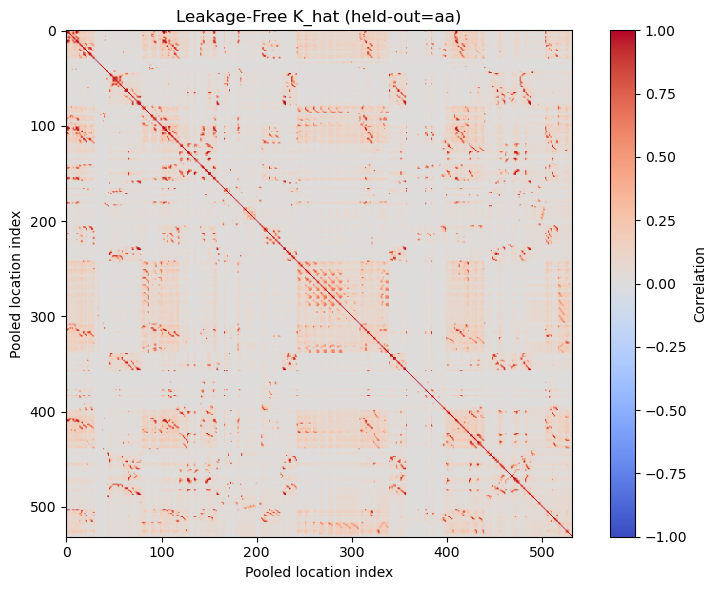

Built leakage-free K_hat matrices for 13 held-out subjects.
Saved leakage-free outputs to /Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/electrode_correlation_outputs_no_leak.npz


In [14]:
# Choose the subject you plan to reconstruct/evaluate
# Compute this expression and store it in `held_out_pid`.
held_out_pid = 'aa'  # <- change as needed
# Assert this assumption and stop if it is violated.
assert held_out_pid in subject_ids, f'{held_out_pid} not found in subject_ids'

# Execute this line as part of the current computation step.
train_ids = [pid for pid in subject_ids if pid != held_out_pid]
# Assert this assumption and stop if it is violated.
assert len(train_ids) > 0, 'Need at least one training subject after hold-out'

# Compute this expression and store it in `train_C_hat_s`.
train_C_hat_s = np.stack([C_hat_s_matrices[pid] for pid in train_ids], axis=0)

# Compute this expression and store it in `mean_z`.
mean_z = fisher_z(train_C_hat_s).mean(axis=0)
# Compute this expression and store it in `K_hat_no_leak`.
K_hat_no_leak = inverse_fisher_z(mean_z).astype(np.float32, copy=False)
# Compute this expression and store it in `K_hat_no_leak`.
K_hat_no_leak = 0.5 * (K_hat_no_leak + K_hat_no_leak.T)
# Set the matrix diagonal entries to the requested value.
np.fill_diagonal(K_hat_no_leak, 1.0)

# Print a status message so you can inspect progress/output.
print(f'Held-out subject: {held_out_pid}')
# Print a status message so you can inspect progress/output.
print(f'Training subjects used to build K_hat: {len(train_ids)}')
# Print a status message so you can inspect progress/output.
print(f'K_hat_no_leak shape: {K_hat_no_leak.shape}')
# Print a status message so you can inspect progress/output.
print(f'min={K_hat_no_leak.min():.4f} max={K_hat_no_leak.max():.4f}')
# Print a status message so you can inspect progress/output.
print(f'max_symmetry_error={np.abs(K_hat_no_leak - K_hat_no_leak.T).max():.6f}')

# Compute this expression and store it in `plt.figure(figsize`.
plt.figure(figsize=(8, 6))
# Compute this expression and store it in `im`.
im = plt.imshow(K_hat_no_leak, cmap='coolwarm', vmin=-1, vmax=1)
# Compute this expression and store it in `plt.colorbar(im, label`.
plt.colorbar(im, label='Correlation')
# Compute this expression and store it in `plt.title(f'Leakage-Free K_hat (held-out`.
plt.title(f'Leakage-Free K_hat (held-out={held_out_pid})')
# Execute this line as part of the current computation step.
plt.xlabel('Pooled location index')
# Execute this line as part of the current computation step.
plt.ylabel('Pooled location index')
# Adjust subplot spacing to reduce label overlap.
plt.tight_layout()
# Render the current figure in the notebook output.
plt.show()

# Optional: build one leakage-free K per possible held-out subject
# Compute this expression and store it in `K_hat_no_leak_by_subject`.
K_hat_no_leak_by_subject = {}
# Start a loop over the specified collection.
for test_pid in subject_ids:
    # Execute this line as part of the current computation step.
    train_ids_i = [pid for pid in subject_ids if pid != test_pid]
    # Compute this expression and store it in `train_stack_i`.
    train_stack_i = np.stack([C_hat_s_matrices[pid] for pid in train_ids_i], axis=0)

    # Compute this expression and store it in `mean_z_i`.
    mean_z_i = fisher_z(train_stack_i).mean(axis=0)
    # Compute this expression and store it in `K_i`.
    K_i = inverse_fisher_z(mean_z_i).astype(np.float32, copy=False)
    # Compute this expression and store it in `K_i`.
    K_i = 0.5 * (K_i + K_i.T)
    # Set the matrix diagonal entries to the requested value.
    np.fill_diagonal(K_i, 1.0)

    # Compute this expression and store it in `K_hat_no_leak_by_subject[test_pid]`.
    K_hat_no_leak_by_subject[test_pid] = K_i

# Print a status message so you can inspect progress/output.
print(f'Built leakage-free K_hat matrices for {len(K_hat_no_leak_by_subject)} held-out subjects.')

# Save both the chosen K and all leave-one-subject-out K matrices
# Compute this expression and store it in `output_path_no_leak`.
output_path_no_leak = project_root / 'electrode_correlation_outputs_no_leak.npz'
# Save the computed outputs to a compressed NPZ file.
np.savez_compressed(
    # Execute this line as part of the current computation step.
    output_path_no_leak,
    # Compute this expression and store it in `pooled_locations_mni_mm`.
    pooled_locations_mni_mm=all_electrodes,
    # Compute this expression and store it in `subject_ids`.
    subject_ids=np.array(subject_ids, dtype=object),
    # Compute this expression and store it in `held_out_pid`.
    held_out_pid=held_out_pid,
    # Compute this expression and store it in `train_ids_for_held_out`.
    train_ids_for_held_out=np.array(train_ids, dtype=object),
    # Compute this expression and store it in `K_hat_no_leak`.
    K_hat_no_leak=K_hat_no_leak,
    # Compute this expression and store it in `K_hat_no_leak_by_subject`.
    K_hat_no_leak_by_subject=np.array([K_hat_no_leak_by_subject[pid] for pid in subject_ids]),
# Close the current argument list or container literal.
)
# Print a status message so you can inspect progress/output.
print(f'Saved leakage-free outputs to {output_path_no_leak}')


# Step 4 — Predict Held-Out Electrode Activity (Paper Eq. 8–10)

In this notebook, we hold out **one electrode** from subject `aa` (electrode index `0`) and predict it from the other `aa` electrodes.

## Equation chain used here (from the paper)

Eq. 1 (Gaussian weights from distance):

$$w_{xi} = \exp\!\left(-\frac{d_{xi}^2}{\lambda}\right)$$

Eq. 6 (subject full-brain matrix from that subject's electrode correlations):

$$\hat{\mathbf{C}}_s = \tanh\!\left(\frac{\mathbf{W}^{(s)}\,\operatorname{arctanh}(\mathbf{C}_s)\,{\mathbf{W}^{(s)}}^\top}{\mathbf{W}^{(s)}\,\mathbf{1}\,{\mathbf{W}^{(s)}}^\top}\right)$$

Eq. 7 (group/leakage-free matrix from training subjects):

$$\hat{\mathbf{K}} = \tanh\!\left(\frac{1}{S_{\text{train}}}\sum_{s \in \text{train}}\operatorname{arctanh}(\hat{\mathbf{C}}_s)\right)$$

Eq. 8 and Eq. 9 (split into observed and held-out index blocks):

$$\hat{\mathbf{K}}_{\beta\alpha}=\hat{\mathbf{K}}(\beta,\alpha), \qquad \hat{\mathbf{K}}_{\alpha\alpha}=\hat{\mathbf{K}}(\alpha,\alpha)$$

Eq. 10 (predict held-out time series):

$$\hat{\mathbf{Y}}_{\beta}=\mathbf{Y}_{\alpha}\,\mathbf{D}^\top, \qquad \mathbf{D}=\hat{\mathbf{K}}_{\beta\alpha}\,\operatorname{pinv}(\hat{\mathbf{K}}_{\alpha\alpha})$$

Interpretation: **$\hat{\mathbf{K}}$ gives fixed decoder weights**, while **$\mathbf{Y}_{\alpha}$ supplies the time-varying samples** at each timepoint.


## Step 4A — Define `alpha`/`beta` and map to pooled indices

- `beta`: held-out electrode(s) we want to predict (here: one electrode)
- `alpha`: observed electrodes from the same subject used as predictors

Index mapping step:

- local subject electrode index list -> pooled location index list
- then select `K_hat_no_leak[np.ix_(beta_pooled_idx, alpha_pooled_idx)]` and `K_hat_no_leak[np.ix_(alpha_pooled_idx, alpha_pooled_idx)]`

Signal preprocessing used before Eq. 10:

$$\mathbf{Y}=\operatorname{zscore}(\text{ecog across time, per channel})$$

So each electrode channel has mean 0 and variance 1 before decoding.


In [15]:
holdout_pid = 'aa'
holdout_local_idx = 0
ridge = 1.0  # stronger regularization helps when Kaa is ill-conditioned/indefinite

assert holdout_pid in subject_records, f'{holdout_pid} not found in subject_records'

pack = np.load(subject_records[holdout_pid]['subject_file'], allow_pickle=True)
ecog = np.asarray(pack['ecog'], dtype=np.float32)                 # (time, electrodes)
locs = np.asarray(pack['locs_mni_mm'], dtype=np.float32)          # (electrodes, 3)

n_time, n_elecs = ecog.shape
assert n_elecs >= 2, 'Need at least 2 electrodes to hold one out'
assert 0 <= holdout_local_idx < n_elecs, 'holdout_local_idx out of range'

# z-score each channel over time
mu = ecog.mean(axis=0, keepdims=True)
sigma = ecog.std(axis=0, keepdims=True)
sigma[sigma < 1e-6] = 1.0
Y = (ecog - mu) / sigma

# map subject electrode coordinates to pooled indices
pooled_keys = {tuple(np.round(all_electrodes[i], 3)): i for i in range(all_electrodes.shape[0])}
subject_pooled_idx = []
for r in np.round(locs, 3):
    key = tuple(r)
    if key not in pooled_keys:
        raise ValueError(f'Could not map subject location {key} into pooled index set')
    subject_pooled_idx.append(pooled_keys[key])

beta_local_idx = [holdout_local_idx]
alpha_local_idx = [i for i in range(n_elecs) if i not in beta_local_idx]

beta_pooled_idx = [subject_pooled_idx[i] for i in beta_local_idx]
alpha_pooled_idx = [subject_pooled_idx[i] for i in alpha_local_idx]

print(f'Hold-out subject: {holdout_pid}')
print(f'Held-out local electrode index (beta): {beta_local_idx}')
print(f'Observed local electrode count (alpha): {len(alpha_local_idx)}')
print(f'n_time={n_time}, n_elecs={n_elecs}, ridge={ridge}')


Hold-out subject: aa
Held-out local electrode index (beta): [0]
Observed local electrode count (alpha): 38
n_time=244200, n_elecs=39, ridge=1.0


## Step 4B — Build Eq. 8/9/10 decoder and predict $\hat{Y}_{\beta}$

Using leakage-free $\hat{K}$:

$$\hat{K}_{\beta,\alpha} = \hat{K}(\beta,\alpha), \qquad \hat{K}_{\alpha,\alpha} = \hat{K}(\alpha,\alpha)$$

(These are Eq. 8 and Eq. 9.)

Decoder matrix:

$$D = \hat{K}_{\beta,\alpha}\,\mathrm{pinv}(\hat{K}_{\alpha,\alpha})$$

Prediction (Eq. 10):

$$\hat{Y}_{\beta} = Y_{\alpha} D^T$$

Expanded for one held-out electrode $b$ at one timepoint $t$:

$$\hat{y}_b(t) = \sum_{j \in \alpha} d_{b,j}\, y_j(t)$$

This is the key mapping:

- $\hat{K}$ does **not** provide time samples
- $\hat{K}$ only provides coefficients $d_{b,j}$
- the instantaneous values $y_j(t)$ come from observed held-out-subject electrodes
- same coefficients are reused for every timepoint; only $Y_{\alpha}(t,:)$ changes over time

Code variable mapping:

- $\hat{K}_{\alpha,\alpha}$ -> `Kaa`
- $\hat{K}_{\beta,\alpha}$ -> `Kba`
- $D$ -> `D`
- $Y_{\alpha}$ -> `Y_alpha`
- $Y_{\beta}$ true/pred -> `Y_beta_true` / `Y_beta_pred`


In [16]:
# Eq. 8/9 blocks from leakage-free K (held-out subject excluded in Step 3C)
Kaa = K_hat_no_leak[np.ix_(alpha_pooled_idx, alpha_pooled_idx)]
Kba = K_hat_no_leak[np.ix_(beta_pooled_idx, alpha_pooled_idx)]

# numerical cleanup
Kaa = np.nan_to_num(Kaa, nan=0.0, posinf=0.0, neginf=0.0)
Kba = np.nan_to_num(Kba, nan=0.0, posinf=0.0, neginf=0.0)

# diagnostics: Kaa can be indefinite, which destabilizes inversion
Kaa_sym = 0.5 * (Kaa + Kaa.T)
eigvals = np.linalg.eigvalsh(Kaa_sym)
print(f'Kaa eig min={eigvals.min():.4f}, max={eigvals.max():.4f}, negative_eigs={(eigvals < 0).sum()}')

# optional PSD projection before inversion (keeps same eigenvectors, clips negative eigvals)
use_psd_projection = True
if use_psd_projection:
    vals, vecs = np.linalg.eigh(Kaa_sym)
    vals = np.clip(vals, 1e-6, None)
    Kaa_used = (vecs * vals) @ vecs.T
else:
    Kaa_used = Kaa_sym

# ridge-regularized inverse for stability
Kaa_reg = Kaa_used + ridge * np.eye(Kaa_used.shape[0], dtype=Kaa_used.dtype)
with np.errstate(over='ignore', divide='ignore', invalid='ignore'):
    D = Kba @ np.linalg.pinv(Kaa_reg, rcond=1e-6)
D = np.nan_to_num(D, nan=0.0, posinf=0.0, neginf=0.0)

Y_alpha = Y[:, alpha_local_idx]                                   # observed within-subject channels
Y_beta_true = Y[:, beta_local_idx]                                # true held-out trace
with np.errstate(over='ignore', divide='ignore', invalid='ignore'):
    Y_beta_pred = (D @ Y_alpha.T).T                               # predicted held-out trace
Y_beta_pred = np.nan_to_num(Y_beta_pred, nan=0.0, posinf=0.0, neginf=0.0)

# reconstruct full matrix only for optional sanity plotting
Y_recon = Y.copy()
Y_recon[:, beta_local_idx] = Y_beta_pred

r_holdout = np.corrcoef(Y_beta_true[:, 0], Y_beta_pred[:, 0])[0, 1]
print(f'Prediction correlation for held-out electrode: r = {r_holdout:.4f}')
print(f'Decoder shape D: {D.shape} | Y_alpha: {Y_alpha.shape} | Y_beta_pred: {Y_beta_pred.shape}')

# simple baselines for context
Caa = np.corrcoef(Y, rowvar=False)
np.fill_diagonal(Caa, 0)
best_idx = int(np.argmax(np.abs(Caa[holdout_local_idx])))
r_best = np.corrcoef(Y[:, holdout_local_idx], Y[:, best_idx])[0, 1]
r_mean = np.corrcoef(Y[:, holdout_local_idx], Y_alpha.mean(axis=1))[0, 1]
print(f'Baseline (best single observed electrode): idx={best_idx}, r={r_best:.4f}')
print(f'Baseline (mean of observed electrodes): r={r_mean:.4f}')


Kaa eig min=-0.5911, max=9.2977, negative_eigs=8
Prediction correlation for held-out electrode: r = 0.3749
Decoder shape D: (1, 38) | Y_alpha: (244200, 38) | Y_beta_pred: (244200, 1)
Baseline (best single observed electrode): idx=1, r=0.5152
Baseline (mean of observed electrodes): r=0.3607


## Step 4C — Visualize and evaluate

You are reconstructing only **one** electrode, so the most informative outputs are:

1. True vs predicted trace for that held-out electrode
2. Single-row heatmaps (true, predicted, error)

Why full-matrix panels can look misleading:

- only one row is replaced
- autoscaling can make panels look very different even when only one row changed

Why low/negative $r$ can happen:

- $K_{\alpha\alpha}$ can be ill-conditioned or indefinite
- inversion then becomes unstable unless regularized
- model may underperform simple within-subject baselines

So this step prints diagnostics and baselines (best single observed electrode, mean-observed trace) alongside Eq. 10 performance.


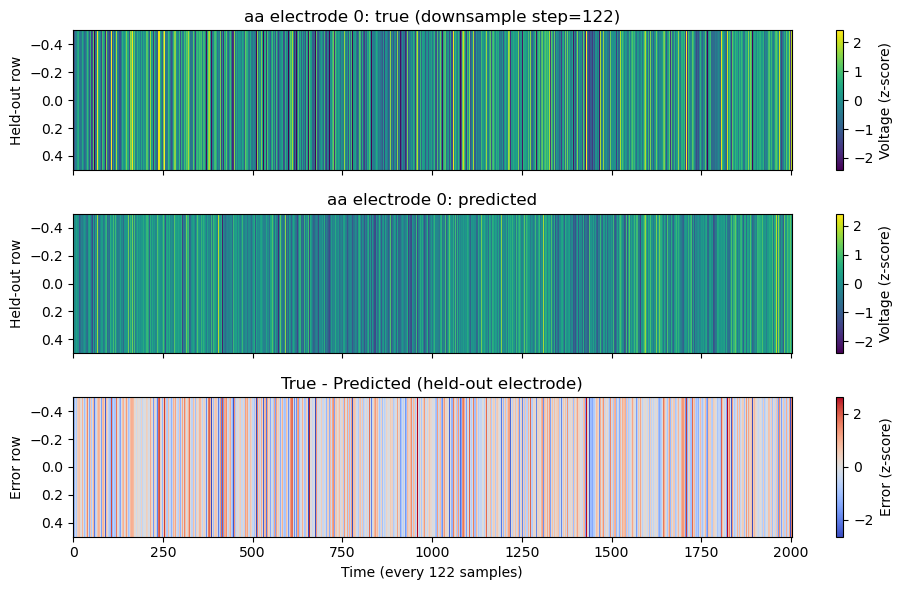

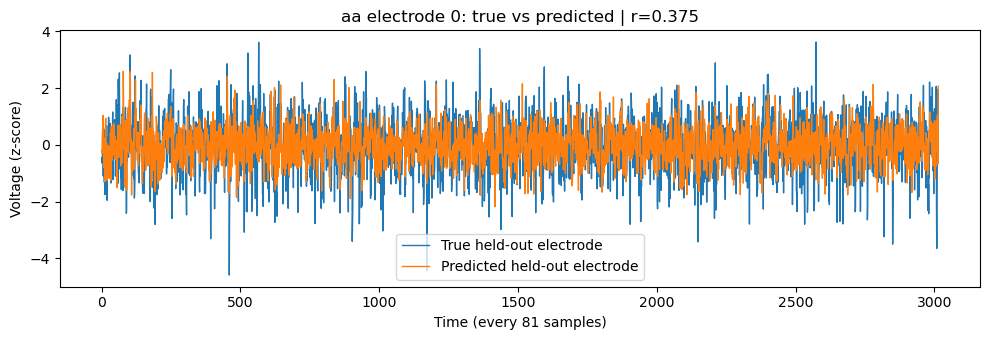

In [17]:
# Focused plots for the single held-out electrode
step = max(1, Y.shape[0] // 2000)
plot_step = max(1, Y.shape[0] // 3000)

true_row = Y_beta_true[::step, 0][None, :]
pred_row = Y_beta_pred[::step, 0][None, :]
err_row = (Y_beta_true[::step, 0] - Y_beta_pred[::step, 0])[None, :]

# Shared range for true/pred panels so colors are directly comparable
shared_lim = np.percentile(np.abs(np.hstack([true_row.ravel(), pred_row.ravel()])), 99)
err_lim = np.percentile(np.abs(err_row.ravel()), 99)
shared_lim = max(shared_lim, 1e-6)
err_lim = max(err_lim, 1e-6)

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

im0 = axes[0].imshow(true_row, aspect='auto', cmap='viridis', vmin=-shared_lim, vmax=shared_lim, interpolation='nearest')
axes[0].set_ylabel('Held-out row')
axes[0].set_title(f'{holdout_pid} electrode {holdout_local_idx}: true (downsample step={step})')
fig.colorbar(im0, ax=axes[0], label='Voltage (z-score)')

im1 = axes[1].imshow(pred_row, aspect='auto', cmap='viridis', vmin=-shared_lim, vmax=shared_lim, interpolation='nearest')
axes[1].set_ylabel('Held-out row')
axes[1].set_title(f'{holdout_pid} electrode {holdout_local_idx}: predicted')
fig.colorbar(im1, ax=axes[1], label='Voltage (z-score)')

im2 = axes[2].imshow(err_row, aspect='auto', cmap='coolwarm', vmin=-err_lim, vmax=err_lim, interpolation='nearest')
axes[2].set_xlabel(f'Time (every {step} samples)')
axes[2].set_ylabel('Error row')
axes[2].set_title('True - Predicted (held-out electrode)')
fig.colorbar(im2, ax=axes[2], label='Error (z-score)')

plt.tight_layout()
plt.show()

# Trace plot
plt.figure(figsize=(10, 3.5))
plt.plot(Y_beta_true[::plot_step, 0], label='True held-out electrode', linewidth=1)
plt.plot(Y_beta_pred[::plot_step, 0], label='Predicted held-out electrode', linewidth=1)
plt.xlabel(f'Time (every {plot_step} samples)')
plt.ylabel('Voltage (z-score)')
plt.title(f'{holdout_pid} electrode {holdout_local_idx}: true vs predicted | r={r_holdout:.3f}')
plt.legend()
plt.tight_layout()
plt.show()


# Optional full-matrix sanity check (off by default because only one row is reconstructed)
show_full_matrix = False
if show_full_matrix:
    step_full = step
    Y_ds = Y[::step_full]
    Y_recon_ds = Y_recon[::step_full]
    full_lim = np.percentile(np.abs(np.hstack([Y_ds.ravel(), Y_recon_ds.ravel()])), 99)
    full_lim = max(full_lim, 1e-6)

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    imA = axes[0].imshow(Y_ds.T, aspect='auto', cmap='viridis', vmin=-full_lim, vmax=full_lim, interpolation='nearest')
    axes[0].set_ylabel('Electrode index')
    axes[0].set_title(f'{holdout_pid}: actual z-scored ECoG (shared scale)')
    fig.colorbar(imA, ax=axes[0], label='Voltage (z-score)')

    imB = axes[1].imshow(Y_recon_ds.T, aspect='auto', cmap='viridis', vmin=-full_lim, vmax=full_lim, interpolation='nearest')
    axes[1].set_xlabel(f'Time (every {step_full} samples)')
    axes[1].set_ylabel('Electrode index')
    axes[1].set_title(f'{holdout_pid}: reconstructed matrix (only electrode {holdout_local_idx} replaced) | r={r_holdout:.3f}')
    fig.colorbar(imB, ax=axes[1], label='Voltage (z-score)')

    # Highlight the single reconstructed row
    for ax in axes:
        ax.axhline(holdout_local_idx - 0.5, color='white', linewidth=1)
        ax.axhline(holdout_local_idx + 0.5, color='white', linewidth=1)

    plt.tight_layout()
    plt.show()


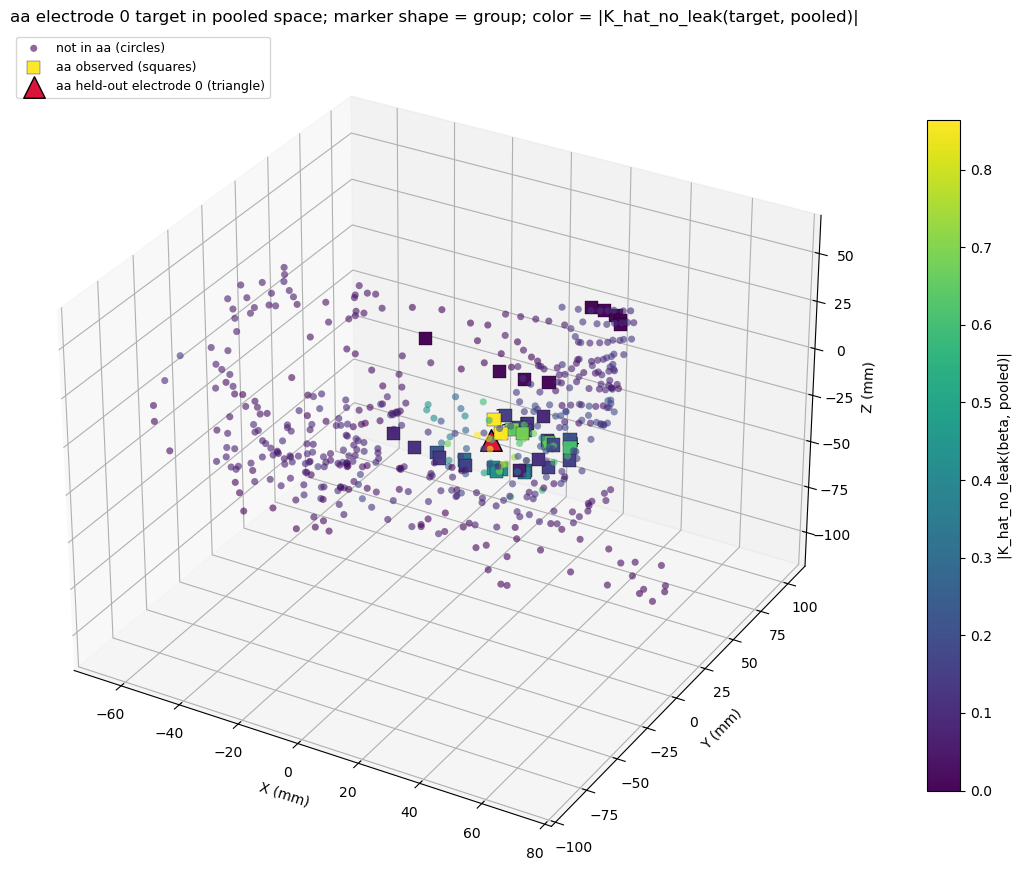

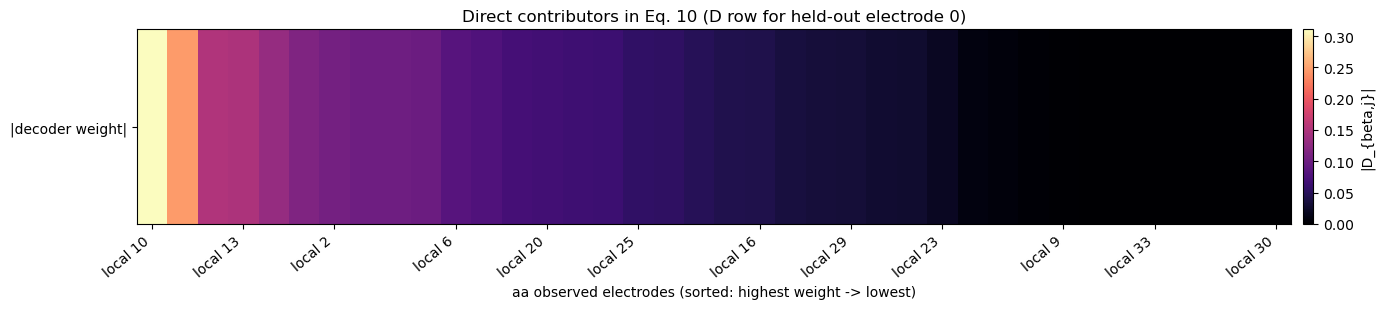

Top contributors for reconstructing aa electrode 0:
 1. aa local 10 | pooled idx  10 | |D|=0.3108 | |K(beta,pooled)|=0.8871
 2. aa local  1 | pooled idx   1 | |D|=0.2459 | |K(beta,pooled)|=0.9198
 3. aa local  7 | pooled idx   7 | |D|=0.1507 | |K(beta,pooled)|=0.1661
 4. aa local 13 | pooled idx  13 | |D|=0.1482 | |K(beta,pooled)|=0.6100
 5. aa local  3 | pooled idx   3 | |D|=0.1316 | |K(beta,pooled)|=0.1684
 6. aa local 26 | pooled idx  26 | |D|=0.1152 | |K(beta,pooled)|=0.4257
 7. aa local  2 | pooled idx   2 | |D|=0.1058 | |K(beta,pooled)|=0.6927
 8. aa local 27 | pooled idx  27 | |D|=0.1019 | |K(beta,pooled)|=0.0684
 9. aa local 21 | pooled idx  21 | |D|=0.1017 | |K(beta,pooled)|=0.3475
10. aa local  8 | pooled idx   8 | |D|=0.0988 | |K(beta,pooled)|=0.1216
11. aa local  6 | pooled idx   6 | |D|=0.0827 | |K(beta,pooled)|=0.1563
12. aa local  4 | pooled idx   4 | |D|=0.0788 | |K(beta,pooled)|=0.1270

Note: only aa observed electrodes have direct decoder weights in Eq.10; non-aa poin

In [18]:
# Step 4D — Which electrodes matter most for reconstructing aa electrode 0?
# Requires Step 4A/4B outputs: holdout_pid, beta_pooled_idx, alpha_pooled_idx, alpha_local_idx, D, K_hat_no_leak, all_electrodes, subject_records

assert holdout_pid == 'aa', f'This cell is set up for aa; got {holdout_pid}'
assert len(beta_pooled_idx) == 1, 'Expected one held-out electrode'
assert D.shape[0] == 1, 'Expected one-row decoder for one held-out electrode'

coords = np.asarray(all_electrodes, dtype=float)
L = coords.shape[0]
beta_pool = int(beta_pooled_idx[0])

# Map aa local electrodes -> pooled indices
pooled_keys = {tuple(np.round(coords[i], 3).tolist()): i for i in range(L)}
aa_pack = np.load(subject_records['aa']['subject_file'], allow_pickle=True)
aa_locs = np.asarray(aa_pack['locs_mni_mm'], dtype=float)
aa_pooled_idx = np.array([pooled_keys[tuple(np.round(r, 3).tolist())] for r in aa_locs], dtype=int)

# Masks for marker styles
in_aa_mask = np.zeros(L, dtype=bool)
in_aa_mask[aa_pooled_idx] = True
holdout_mask = np.zeros(L, dtype=bool)
holdout_mask[beta_pool] = True
aa_obs_mask = in_aa_mask & (~holdout_mask)
non_aa_mask = ~in_aa_mask

# All-pooled coupling score from leakage-free K (how strongly each pooled location couples to target location)
all_pooled_coupling = np.abs(np.asarray(K_hat_no_leak[beta_pool, :], dtype=float))
all_pooled_coupling[beta_pool] = np.nan
coupling_vmax = np.nanpercentile(all_pooled_coupling, 99)
coupling_vmax = max(coupling_vmax, 1e-6)

# Decoder weights from Eq. 10 (these are the direct contributors to reconstruction)
decoder_abs = np.abs(np.asarray(D[0], dtype=float))
alpha_local_arr = np.asarray(alpha_local_idx, dtype=int)
alpha_pooled_arr = np.asarray(alpha_pooled_idx, dtype=int)
order = np.argsort(decoder_abs)[::-1]

# Figure 1 (large): 3D pooled geometry with requested marker styles
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(1, 1, 1, projection='3d')

# non-aa pooled points: circles
ax.scatter(
    coords[non_aa_mask, 0], coords[non_aa_mask, 1], coords[non_aa_mask, 2],
    c=all_pooled_coupling[non_aa_mask], cmap='viridis', vmin=0, vmax=coupling_vmax,
    s=26, marker='o', alpha=0.60, linewidths=0, label='not in aa (circles)'
)

# aa observed points: squares
sc_aa = ax.scatter(
    coords[aa_obs_mask, 0], coords[aa_obs_mask, 1], coords[aa_obs_mask, 2],
    c=all_pooled_coupling[aa_obs_mask], cmap='viridis', vmin=0, vmax=coupling_vmax,
    s=90, marker='s', edgecolor='black', linewidth=0.25, alpha=0.98, label='aa observed (squares)'
)

# held-out aa electrode 0: triangle
ax.scatter(
    coords[beta_pool, 0], coords[beta_pool, 1], coords[beta_pool, 2],
    c='crimson', s=240, marker='^', edgecolor='black', linewidth=1.0,
    label='aa held-out electrode 0 (triangle)'
)

# Label top 5 decoder contributors on the 3D plot (rank numbers)
top_n_labels = min(5, len(order))
for rank in range(top_n_labels):
    pooled_j = int(alpha_pooled_arr[order[rank]])
    x, y, z = coords[pooled_j]
    ax.text(x, y, z, f'{rank+1}', fontsize=10, color='black')

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Z (mm)')
ax.set_title('aa electrode 0 target in pooled space; marker shape = group; color = |K_hat_no_leak(target, pooled)|')
cb = fig.colorbar(sc_aa, ax=ax, fraction=0.03, pad=0.06)
cb.set_label('|K_hat_no_leak(beta, pooled)|')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# Figure 2: Decoder-weight heatmap (direct Eq.10 importance for aa observed electrodes only)
fig2, ax2 = plt.subplots(figsize=(14, 3.2))
heat = decoder_abs[order][None, :]
im = ax2.imshow(heat, aspect='auto', cmap='magma', interpolation='nearest')
ax2.set_yticks([0])
ax2.set_yticklabels(['|decoder weight|'])
ax2.set_xlabel('aa observed electrodes (sorted: highest weight -> lowest)')
ax2.set_title('Direct contributors in Eq. 10 (D row for held-out electrode 0)')

xtick_n = min(12, heat.shape[1])
xticks = np.linspace(0, heat.shape[1] - 1, xtick_n, dtype=int)
ax2.set_xticks(xticks)
ax2.set_xticklabels([f'local {alpha_local_arr[order[i]]}' for i in xticks], rotation=40, ha='right')

cb2 = fig2.colorbar(im, ax=ax2, fraction=0.03, pad=0.01)
cb2.set_label('|D_{beta,j}|')
plt.tight_layout()
plt.show()

# Print top contributors with both direct decoder weight and pooled-coupling score
top_n = min(12, len(order))
print('Top contributors for reconstructing aa electrode 0:')
for rank in range(top_n):
    j = order[rank]
    local_j = int(alpha_local_arr[j])
    pooled_j = int(alpha_pooled_arr[j])
    w = float(decoder_abs[j])
    k = float(all_pooled_coupling[pooled_j])
    print(f'{rank+1:2d}. aa local {local_j:2d} | pooled idx {pooled_j:3d} | |D|={w:.4f} | |K(beta,pooled)|={k:.4f}')

print('')
print('Note: only aa observed electrodes have direct decoder weights in Eq.10; non-aa points influence reconstruction indirectly through K_hat_no_leak.')


# ------- MULTI-ELECTRODE PREDICTION --------

In [19]:


holdout_pid = 'aa'
holdout_local_idx = 0
ridge = 1.0  # stronger regularization helps when Kaa is ill-conditioned/indefinite

assert holdout_pid in subject_records, f'{holdout_pid} not found in subject_records'

pack = np.load(subject_records[holdout_pid]['subject_file'], allow_pickle=True)
ecog = np.asarray(pack['ecog'], dtype=np.float32)                 # (time, electrodes)
locs = np.asarray(pack['locs_mni_mm'], dtype=np.float32)          # (electrodes, 3)

n_time, n_elecs = ecog.shape
assert n_elecs >= 2, 'Need at least 2 electrodes to hold one out'
assert 0 <= holdout_local_idx < n_elecs, 'holdout_local_idx out of range'

# z-score each channel over time
mu = ecog.mean(axis=0, keepdims=True)
sigma = ecog.std(axis=0, keepdims=True)
sigma[sigma < 1e-6] = 1.0
Y = (ecog - mu) / sigma

# map subject electrode coordinates to pooled indices
pooled_keys = {tuple(np.round(all_electrodes[i], 3)): i for i in range(all_electrodes.shape[0])}
subject_pooled_idx = []
for r in np.round(locs, 3):
    key = tuple(r)
    if key not in pooled_keys:
        raise ValueError(f'Could not map subject location {key} into pooled index set')
    subject_pooled_idx.append(pooled_keys[key])

beta_local_idx = [holdout_local_idx]
alpha_local_idx = [i for i in range(n_elecs) if i not in beta_local_idx]

beta_pooled_idx = [subject_pooled_idx[i] for i in beta_local_idx]
alpha_pooled_idx = [subject_pooled_idx[i] for i in alpha_local_idx]

print(f'Hold-out subject: {holdout_pid}')
print(f'Held-out local electrode index (beta): {beta_local_idx}')
print(f'Observed local electrode count (alpha): {len(alpha_local_idx)}')
print(f'n_time={n_time}, n_elecs={n_elecs}, ridge={ridge}')


Hold-out subject: aa
Held-out local electrode index (beta): [0]
Observed local electrode count (alpha): 38
n_time=244200, n_elecs=39, ridge=1.0


In [20]:
# choose multiple beta electrodes (example)
beta_local_idx = [0, 3, 7, 12]

# alpha = all remaining electrodes
alpha_local_idx = [i for i in range(n_elecs) if i not in beta_local_idx]

# map to pooled indices
beta_pooled_idx = [subject_pooled_idx[i] for i in beta_local_idx]
alpha_pooled_idx = [subject_pooled_idx[i] for i in alpha_local_idx]

print('beta:', beta_local_idx)
print('alpha count:', len(alpha_local_idx))



beta: [0, 3, 7, 12]
alpha count: 35
